In [172]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
import matplotlib.patches as mpatches

plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11

In [173]:
def compute_jacobian(phi1, phi2, params):
    """计算Jacobian和特征值"""
    k1, k2 = params['k1'], params['k2']
    beta1, beta2 = params['beta_J1'], params['beta_J2']
    
    j11 = (-np.cos(phi1) - k1) / beta1
    j12 = k1 / beta1
    j21 = k2 / beta2
    j22 = (-np.cos(phi2) - k2) / beta2
    
    J = np.array([[j11, j12], [j21, j22]])
    eigenvalues = np.linalg.eigvals(J)
    return J, eigenvalues


In [174]:

def classify_point(eigenvalues):
    """根据特征值分类"""
    ev1, ev2 = eigenvalues
    re1, re2 = np.real(ev1), np.real(ev2)
    im1, im2 = np.imag(ev1), np.imag(ev2)
    
    eps = 1e-10
    
    is_real = (abs(im1) < eps) and (abs(im2) < eps)
    
    if is_real:
        if re1 < -eps and re2 < -eps:
            return 'stable_node'
        elif (re1 > -eps and re2 < -eps) or (re1 < -eps and re2 > -eps):
            return 'saddle_node'
        elif re1 > -eps and re2 > -eps:
            return 'unstable'
    else:
        if re1 < -eps and re2 < -eps:
            return 'stable_focus'
        elif (re1 > -eps and re2 < -eps) or (re1 < -eps and re2 > -eps):
            return 'saddle_focus'
        elif re1 > -eps and re2 > -eps:
            return 'unstable'
    return 'unknown'


In [175]:

def find_fixed_points_robust(params, num_guess=120):
    """在[-pi, pi]范围内寻找所有不动点"""
    i1, i2, k1, k2 = params['i1'], params['i2'], params['k1'], params['k2']
    
    def equations(vars):
        phi1, phi2 = vars
        eq1 = i1 - np.sin(phi1) + k1 * (phi2 - phi1)
        eq2 = i2 - np.sin(phi2) + k2 * (phi1 - phi2)
        return [eq1, eq2]
    
    fixed_points = []
    tolerance = 1e-5
    
    # 只在 [-pi, pi] 范围内搜索
    phi_range = np.linspace(0, 2*np.pi, num_guess)
    
    for p1_guess in phi_range:
        for p2_guess in phi_range:
            try:
                sol, info, ier, mesg = fsolve(equations, [p1_guess, p2_guess], 
                                              full_output=True, xtol=1e-12, maxfev=300)
                if ier == 1:
                    phi1, phi2 = sol
                    # 检查是否在 [-pi, pi] 范围内
                    if not (0 - 1e-6 <= phi1 <= 2*np.pi + 1e-6 and 
                           0 - 1e-6 <= phi2 <= 2*np.pi + 1e-6):
                        continue
                    
                    # 检查残差
                    residual = np.max(np.abs(equations(sol)))
                    if residual > 1e-8:
                        continue
                    
                    # 标准化到 [-pi, pi]
                    phi1_mod = max(0, min(2*np.pi, phi1))
                    phi2_mod = max(0, min(2*np.pi, phi2))
                    
                    # 检查是否已存在
                    is_new = True
                    for fp in fixed_points:
                        d1 = abs(fp['phi1'] - phi1_mod)
                        d2 = abs(fp['phi2'] - phi2_mod)
                        if d1 < tolerance and d2 < tolerance:
                            is_new = False
                            break
                    
                    if is_new:
                        J, ev = compute_jacobian(phi1, phi2, params)
                        stab = classify_point(ev)
                        fixed_points.append({
                            'phi1': phi1_mod,
                            'phi2': phi2_mod,
                            'stability': stab,
                            'eigenvalues': ev,
                            'residual': residual
                        })
            except:
                continue
    
    fixed_points.sort(key=lambda x: (x['phi1'], x['phi2']))
    return fixed_points


In [176]:

def plot_nullclines_strict(ax, params):
    """
    严格在[-pi, pi]范围内绘制零斜线
    只绘制phi1, phi2都在范围内的部分
    """
    i1, i2, k1, k2 = params['i1'], params['i2'], params['k1'], params['k2']
    
    # 生成密集的phi值
    phi_dense = np.linspace(0, 2*np.pi, 2000)
    
    # ========== phi1-nullcline: i1 - sin(phi1) + k1*(phi2-phi1) = 0 ==========
    # => phi2 = phi1 - (i1 - sin(phi1))/k1
    phi1_nc1 = phi_dense
    phi2_nc1 = phi_dense - (i1 - np.sin(phi_dense))/k1
    
    # 只保留在[-pi, pi]范围内的点
    mask1 = (phi2_nc1 >= 0) & (phi2_nc1 <= 2*np.pi)
    phi1_plot1 = phi1_nc1[mask1]
    phi2_plot1 = phi2_nc1[mask1]
    
    # 分割不连续的部分
    segments1 = []
    if len(phi1_plot1) > 0:
        current_seg = [(phi1_plot1[0], phi2_plot1[0])]
        for i in range(1, len(phi1_plot1)):
            if abs(phi1_plot1[i] - phi1_plot1[i-1]) < 0.01 and abs(phi2_plot1[i] - phi2_plot1[i-1]) < 0.5:
                current_seg.append((phi1_plot1[i], phi2_plot1[i]))
            else:
                if len(current_seg) > 1:
                    segments1.append(current_seg)
                current_seg = [(phi1_plot1[i], phi2_plot1[i])]
        if len(current_seg) > 1:
            segments1.append(current_seg)
    
    # 绘制phi1-nullcline（黑色）
    for seg in segments1:
        x_vals = [p[0] for p in seg]
        y_vals = [p[1] for p in seg]
        ax.plot(x_vals, y_vals, 'k-', linewidth=2)
    
    # ========== phi2-nullcline: i2 - sin(phi2) + k2*(phi1-phi2) = 0 ==========
    # => phi1 = phi2 - (i2 - sin(phi2))/k2
    phi2_nc2 = phi_dense
    phi1_nc2 = phi_dense - (i2 - np.sin(phi_dense))/k2
    
    # 只保留在[-pi, pi]范围内的点
    mask2 = (phi1_nc2 >= 0) & (phi1_nc2 <= 2*np.pi)
    phi2_plot2 = phi2_nc2[mask2]
    phi1_plot2 = phi1_nc2[mask2]
    
    # 分割不连续的部分
    segments2 = []
    if len(phi1_plot2) > 0:
        current_seg = [(phi1_plot2[0], phi2_plot2[0])]
        for i in range(1, len(phi1_plot2)):
            if abs(phi1_plot2[i] - phi1_plot2[i-1]) < 0.5 and abs(phi2_plot2[i] - phi2_plot2[i-1]) < 0.01:
                current_seg.append((phi1_plot2[i], phi2_plot2[i]))
            else:
                if len(current_seg) > 1:
                    segments2.append(current_seg)
                current_seg = [(phi1_plot2[i], phi2_plot2[i])]
        if len(current_seg) > 1:
            segments2.append(current_seg)
    
    # 绘制phi2-nullcline（红色）
    for seg in segments2:
        x_vals = [p[0] for p in seg]
        y_vals = [p[1] for p in seg]
        ax.plot(x_vals, y_vals, 'r-', linewidth=1.5, alpha=0.8)


In [177]:

from matplotlib.axes import Axes


def _split_segments(x, y, threshold=0.5):
    segments = []
    if len(x) == 0:
        return segments
    current_seg = [(x[0], y[0])]
    for i in range(1, len(x)):
        if abs(x[i] - x[i-1]) < threshold and abs(y[i] - y[i-1]) < threshold:
            current_seg.append((x[i], y[i]))
        else:
            if len(current_seg) > 1:
                segments.append(current_seg)
            current_seg = [(x[i], y[i])]
    if len(current_seg) > 1:
        segments.append(current_seg)
    return segments

def plot_nullclines_global(ax, params):
    """在全局范围内绘制零斜线（使用周期复制方法，支持任意范围）"""
    i1, i2, k1, k2 = params['i1'], params['i2'], params['k1'], params['k2']
    
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    min_m = int(np.floor((min(xlim[0], ylim[0]) - 2*np.pi) / (2*np.pi))) - 1
    max_m = int(np.ceil((max(xlim[1], ylim[1]) + 2*np.pi) / (2*np.pi))) + 1
    
    phi_dense = np.linspace(0, 2*np.pi, 2000)
    
    # phi1-nullcline: phi2 = phi1 + (sin(phi1) - i1)/k1
    phi1_base = phi_dense
    phi2_base = phi_dense + (np.sin(phi_dense) - i1) / k1
    
    segments1 = []
    for m in range(min_m, max_m + 1):
        p1 = phi1_base + 2*np.pi*m
        p2 = phi2_base + 2*np.pi*m
        mask = (p1 >= xlim[0]) & (p1 <= xlim[1]) & (p2 >= ylim[0]) & (p2 <= ylim[1])
        p1m, p2m = p1[mask], p2[mask]
        segments1.extend(_split_segments(p1m, p2m, threshold=0.5))
    
    for seg in segments1:
        x_vals = [p[0] for p in seg]
        y_vals = [p[1] for p in seg]
        ax.plot(x_vals, y_vals, 'k-', linewidth=1.5, alpha=0.75)
    
    # phi2-nullcline: phi1 = phi2 + (sin(phi2) - i2)/k2
    phi2_base2 = phi_dense
    phi1_base2 = phi_dense + (np.sin(phi_dense) - i2) / k2
    
    segments2 = []
    for m in range(min_m, max_m + 1):
        p1 = phi1_base2 + 2*np.pi*m
        p2 = phi2_base2 + 2*np.pi*m
        mask = (p1 >= xlim[0]) & (p1 <= xlim[1]) & (p2 >= ylim[0]) & (p2 <= ylim[1])
        p1m, p2m = p1[mask], p2[mask]
        segments2.extend(_split_segments(p1m, p2m, threshold=0.5))
    
    for seg in segments2:
        x_vals = [p[0] for p in seg]
        y_vals = [p[1] for p in seg]
        ax.plot(x_vals, y_vals, 'r-', linewidth=1.2, alpha=0.65)


def plot_phase_portrait_strict(ax: Axes, params, title_suffix="", label=""):
    """绘制全局相图，并在右上角用 inset 放大 [0, 2pi] 区域并标注不动点"""
    i1, i2, k1, k2 = params['i1'], params['i2'], params['k1'], params['k2']
    
    # 1. 先设置主图范围，使全局零斜线能根据范围正确绘制
    ax.set_xlim([-5*np.pi, 10*np.pi])
    ax.set_ylim([-5*np.pi, 10*np.pi])
    
    # 2. 绘制全局零斜线
    plot_nullclines_global(ax, params)
    
    # 3. 创建 inset axes（位于主图右上角）
    inset_ax = ax.inset_axes([0.08, 0.55, 0.40, 0.40])
    
    # 3. 在 inset 中绘制 [0, 2pi] 零斜线
    plot_nullclines_strict(inset_ax, params)
    
    # 4. 寻找并在 inset 中绘制不动点
    fps = find_fixed_points_robust(params, num_guess=150)
    print(f"\n[{label}] i={i1}, k={k1}: Found {len(fps)} fixed points in [0, 2π]")
    
    marker_styles = {
        'stable_node':   {'marker': 'o', 'markerfacecolor': 'black', 'markeredgecolor': 'black'},
        'saddle_node':   {'marker': 'o', 'markerfacecolor': 'white', 'markeredgecolor': 'black'},
        'stable_focus':  {'marker': 's', 'markerfacecolor': 'black', 'markeredgecolor': 'black'},
        'saddle_focus':  {'marker': 's', 'markerfacecolor': 'white', 'markeredgecolor': 'black'},
        'unstable':      {'marker': '^', 'markerfacecolor': 'white', 'markeredgecolor': 'black'},
        'unknown':       {'marker': 'D', 'markerfacecolor': 'gray', 'markeredgecolor': 'black'},
    }
    
    for i, fp in enumerate(fps):
        p1, p2 = fp['phi1'], fp['phi2']
        stab = fp['stability']
        ev = fp['eigenvalues']
        
        if np.allclose(np.imag(ev), 0):
            ev_str = f"{np.real(ev[0]):+7.3f}, {np.real(ev[1]):+7.3f}"
        else:
            ev_str = f"{ev[0]:+7.3f}, {ev[1]:+7.3f}"
        print(f"  {i+1:2d}. ({p1:+.4f}, {p2:+.4f}) {stab:15s} | EV: {ev_str}")
        
        style = marker_styles.get(stab, marker_styles['unknown'])
        inset_ax.plot(p1, p2, linestyle='None', markersize=5, zorder=10, **style)
    
    # 5. 设置主图范围与样式
    ax.set_xlim([-5*np.pi, 10*np.pi])
    ax.set_ylim([-5*np.pi, 10*np.pi])
    ax.set_aspect('equal')
    ax.set_xlabel(r'$\phi_1$', fontsize=10)
    ax.set_ylabel(r'$\phi_2$', fontsize=10)
    ax.set_title(f"{label}  i={i1:.1f}, κ={k1:.2f}  {title_suffix}", fontsize=9)
    ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.3)
    ax.plot([-5*np.pi, 10*np.pi], [-5*np.pi, 10*np.pi], 'k--', alpha=0.15, linewidth=0.6)
    
    # 6. 设置 inset 范围与样式
    inset_ax.set_facecolor("#C1C1C1")
    inset_ax.set_xlim([0, 2*np.pi])
    inset_ax.set_ylim([0, 2*np.pi])
    inset_ax.set_aspect('equal')
    inset_ax.set_xticks([0, np.pi, 2*np.pi])
    inset_ax.set_xticklabels(['0', r'$\pi$', r'$2\pi$'], fontsize=7)
    inset_ax.set_yticks([0, np.pi, 2*np.pi])
    inset_ax.set_yticklabels(['0', r'$\pi$', r'$2\pi$'], fontsize=7)
    inset_ax.tick_params(axis='both', which='both', labelsize=7, colors='blue', labelcolor='blue')
    inset_ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.3)
    inset_ax.plot([0, 2*np.pi], [0, 2*np.pi], 'k--', alpha=0.2, linewidth=0.5)
    
    # 7. 添加 inset 缩放指示框
    ax.indicate_inset_zoom(inset_ax, edgecolor="gray", linewidth=1.0, alpha=0.5)
    
    return fps


[(a)] i=1.0, k=0.05: Found 1 fixed points in [0, 2π]
   1. (+1.5708, +1.5708) stable_node     | EV:  -0.000,  -1.000

[(b)] i=0.95, k=0.05: Found 4 fixed points in [0, 2π]
   1. (+1.2532, +1.2532) stable_node     | EV:  -3.122,  -4.122
   2. (+1.3711, +1.9739) saddle_node     | EV:  -2.525,  +3.464
   3. (+1.8884, +1.8884) unstable        | EV:  +2.122,  +3.122
   4. (+1.9739, +1.3711) saddle_node     | EV:  +3.464,  -2.525

[(c)] i=0.8, k=0.05: Found 4 fixed points in [0, 2π]
   1. (+0.9273, +0.9273) stable_node     | EV:  -6.000,  -7.000
   2. (+1.0423, +2.3138) saddle_node     | EV:  -5.563,  +6.286
   3. (+2.2143, +2.2143) unstable        | EV:  +6.000,  +5.000
   4. (+2.3138, +1.0423) saddle_node     | EV:  +6.286,  -5.563

[(d)] i=0.3, k=0.05: Found 4 fixed points in [0, 2π]
   1. (+0.3047, +0.3047) stable_node     | EV:  -9.539, -10.539
   2. (+0.4404, +2.9670) saddle_node     | EV:  -9.559,  +9.361
   3. (+2.8369, +2.8369) unstable        | EV:  +9.539,  +8.539
   4. (+2.9670,

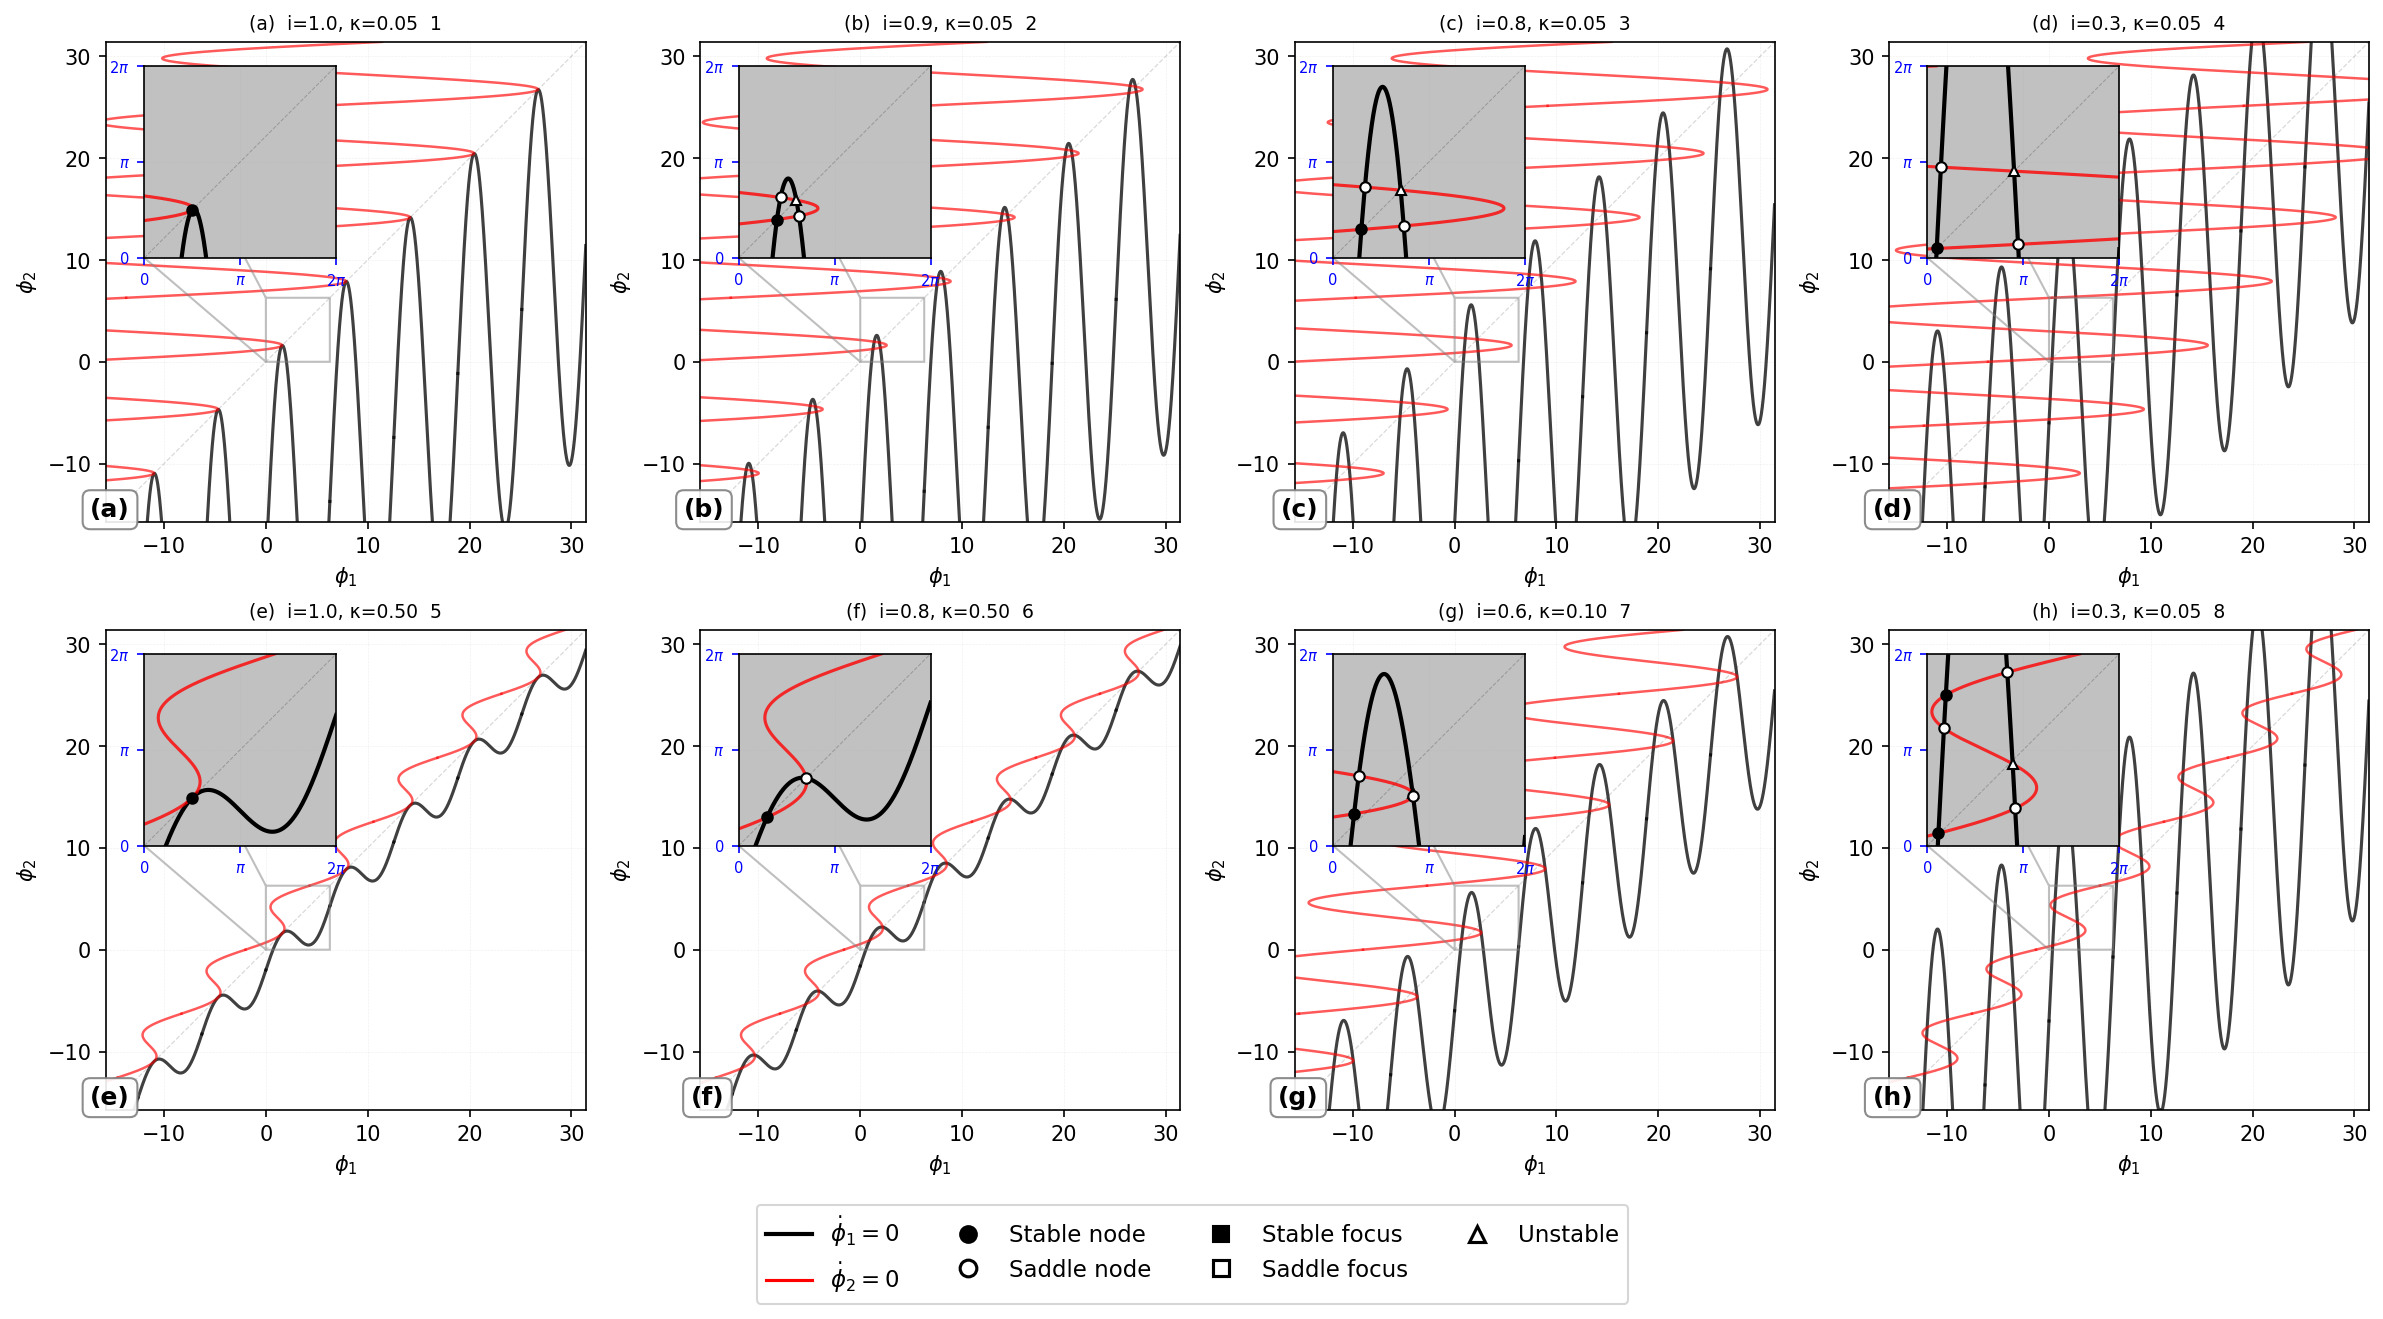

In [181]:
param_sets = [
    (1.0, 1.0, 0.1, 0.1, 0.05, 0.05, "1"),
    (0.95, 0.95, 0.1, 0.1, 0.05, 0.05, "2"),
    (0.8, 0.8, 0.1, 0.1, 0.05, 0.05, "3"),
    (0.3, 0.3, 0.1, 0.1, 0.05, 0.05, "4"),
    (1.0, 1.0, 0.1, 0.1, 0.50, 0.50, "5"),
    (0.8, 0.8, 0.1, 0.1, 0.50, 0.50, "6"),
    (0.6, 0.9, 0.1, 0.1, 0.10, 0.10, "7"),
    (0.35, 0.41, 0.1, 0.1, 0.05, 0.32, "8"),
]

plt.rcParams['figure.dpi'] = 150

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, (i1, i2, b1, b2, k1, k2, desc) in enumerate(param_sets):
    params = {
        'i1': i1, 'i2': i2, 
        'beta_J1': b1, 'beta_J2': b2,
        'k1': k1, 'k2': k2
    }
    ax = axes[idx]
    label = f"({chr(97+idx)})"
    fps = plot_phase_portrait_strict(ax, params, desc, label)
    
    # 添加图例标签
    ax.text(0.05, 0.05, label, transform=ax.transAxes, 
            fontsize=12, fontweight='bold', va='top', ha='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

# 图例
legend_elements = [
    plt.Line2D([0], [0], color='black', linewidth=2, label=r'$\dot{\phi}_1=0$'),
    plt.Line2D([0], [0], color='red', linewidth=1.5, label=r'$\dot{\phi}_2=0$'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='black', 
               markeredgecolor='black', markersize=8, linestyle='None', label='Stable node'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='white', 
               markeredgecolor='black', markeredgewidth=1.5, markersize=8, linestyle='None', label='Saddle node'),
    plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='black', 
               markeredgecolor='black', markersize=8, linestyle='None', label='Stable focus'),
    plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='white', 
               markeredgecolor='black', markeredgewidth=1.5, markersize=8, linestyle='None', label='Saddle focus'),
    plt.Line2D([0], [0], marker='^', color='w', markerfacecolor='white', 
               markeredgecolor='black', markeredgewidth=1.5, markersize=8, linestyle='None', label='Unstable'),
]

fig.legend(handles=legend_elements, loc='lower center', ncol=4, 
          bbox_to_anchor=(0.5, -0.1), fontsize=11)

plt.tight_layout(h_pad=1)
plt.show()